In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Image preprocessing

In [2]:
transform= transforms.ToTensor()

train_ds= torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)


test_ds = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]


In [3]:
image,label= train_ds[0]

type(image), image.shape, label

(torch.Tensor, torch.Size([1, 28, 28]), 5)

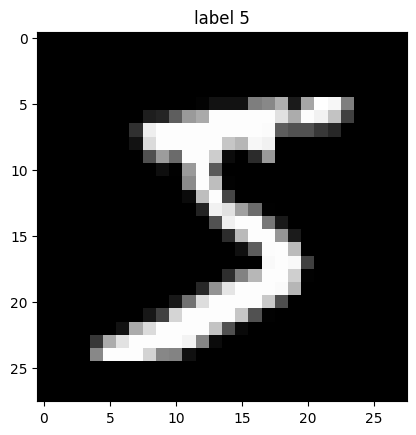

In [4]:
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"label {label}")
plt.show()

In [5]:
train_loader= torch.utils.data.DataLoader(
    dataset=train_ds,
    batch_size=64,
    shuffle=True
)

test_loader=torch.utils.data.DataLoader(
    dataset=test_ds,
    batch_size=64,
    shuffle=False
)


## Making Model

In [6]:
import torch.nn as nn

class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Conv layers
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Activation + Pool
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

        # Regularization
        self.dropout = nn.Dropout(0.3)

        # Fully connected
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Conv Block 1
        x = self.pool(self.relu(self.bn1(self.conv1(x))))  # 28 → 14

        # Conv Block 2
        x = self.pool(self.relu(self.bn2(self.conv2(x))))  # 14 → 7

        # Conv Block 3
        x = self.pool(self.relu(self.bn3(self.conv3(x))))  # 7 → 3

        # Flatten
        x = x.view(x.size(0), -1)

        # FC
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [7]:
import torch

model = MyCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [9]:

epochs=5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

Epoch [1/5], Loss: 117.1936
Epoch [2/5], Loss: 46.7728
Epoch [3/5], Loss: 34.8435
Epoch [4/5], Loss: 28.1282
Epoch [5/5], Loss: 21.9026


In [10]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.04%


In [11]:
images, labels = next(iter(test_loader))

images = images.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

print("Predicted:", predicted[0].item())
print("Actual:", labels[0].item())

Predicted: 7
Actual: 7


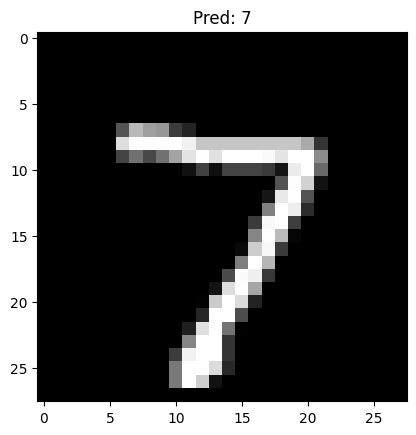

In [12]:
import matplotlib.pyplot as plt

plt.imshow(images[0].cpu().squeeze(), cmap='gray')
plt.title(f"Pred: {predicted[0].item()}")
plt.show()

In [13]:
for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # 🔥 evaluation per epoch
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total

    print(f"Epoch {epoch+1}: Loss={running_loss:.2f}, Acc={acc:.2f}%")

Epoch 1: Loss=19.72, Acc=98.98%
Epoch 2: Loss=18.36, Acc=99.12%
Epoch 3: Loss=13.78, Acc=99.34%
Epoch 4: Loss=12.22, Acc=99.19%
Epoch 5: Loss=12.37, Acc=99.26%


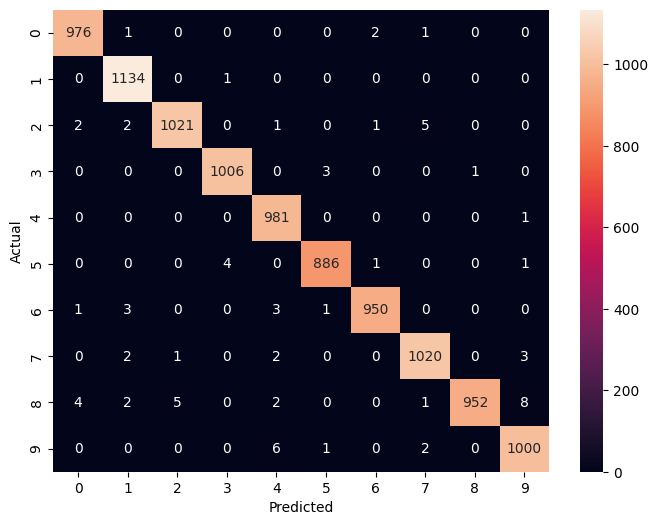

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                wrong_images.append(images[i].cpu())
                wrong_preds.append(predicted[i].item())
                wrong_labels.append(labels[i].item())

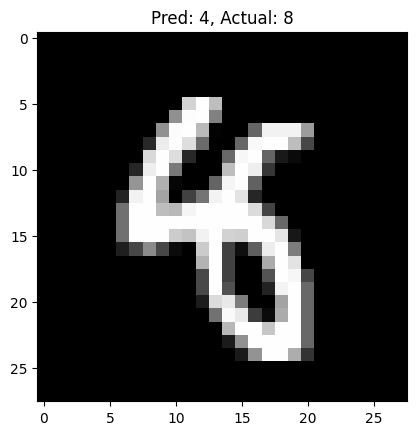

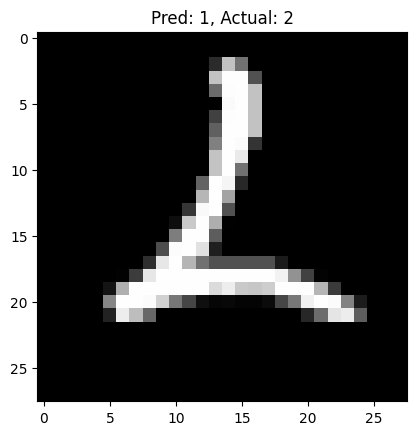

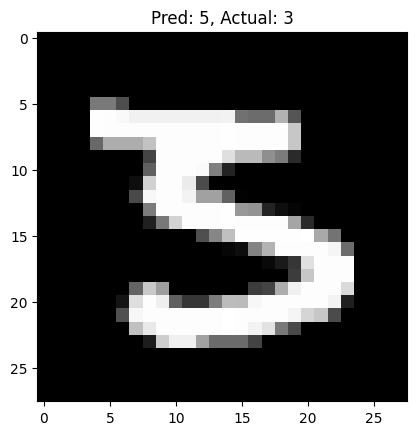

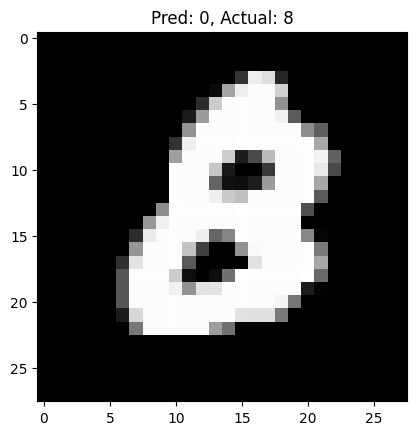

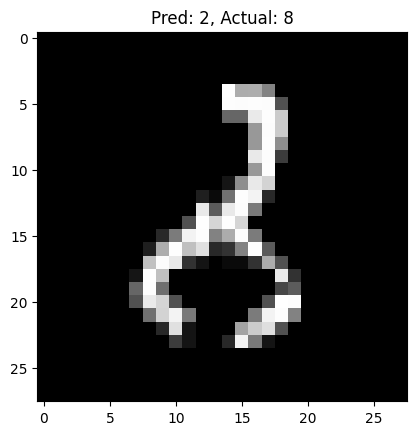

In [16]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(wrong_images[i].squeeze(), cmap='gray')
    plt.title(f"Pred: {wrong_preds[i]}, Actual: {wrong_labels[i]}")
    plt.show()

In [17]:
torch.save(model.state_dict(), "mycnn.pth")

# LetNet

In [18]:
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.AvgPool2d(2)
        self.conv2 = nn.Conv2d(6, 16, 5)

        self.fc1 = nn.Linear(16*4*4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [19]:
model = LeNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 369.1778
Epoch 2, Loss: 109.1878
Epoch 3, Loss: 74.0143
Epoch 4, Loss: 58.1611
Epoch 5, Loss: 49.8343


In [20]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"LeNet Accuracy: {accuracy:.2f}%")

LeNet Accuracy: 98.27%


In [21]:
torch.save(model.state_dict(), "lenet.pth")

# ResNet

In [22]:
import torchvision.models as models
import torch.nn as nn

def get_resnet():
    model = models.resnet18(pretrained=False)

    # MNIST → 1 channel
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # output layer → 10 class
    model.fc = nn.Linear(model.fc.in_features, 10)

    return model

In [23]:
model = get_resnet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [24]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 125.4722
Epoch 2, Loss: 59.1566
Epoch 3, Loss: 41.2910
Epoch 4, Loss: 37.0317
Epoch 5, Loss: 30.3614


In [25]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"ResNet Accuracy: {accuracy:.2f}%")

ResNet Accuracy: 98.86%


In [26]:
torch.save(model.state_dict(), "resnet.pth")

# MobileNet

In [28]:
import torchvision.models as models
import torch.nn as nn

def get_mobilenet():
    model = models.mobilenet_v2(pretrained=False)

    # MNIST → 1 channel input
    model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)

    # output → 10 class
    model.classifier[1] = nn.Linear(model.last_channel, 10)

    return model

In [29]:
model = get_mobilenet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [30]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 483.5110
Epoch 2, Loss: 131.8361
Epoch 3, Loss: 99.4660
Epoch 4, Loss: 78.8173
Epoch 5, Loss: 66.4646


In [31]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"MobileNet Accuracy: {accuracy:.2f}%")

MobileNet Accuracy: 98.48%


In [32]:
torch.save(model.state_dict(), "mobilenet.pth")

Onnox JS

In [48]:
!pip install onnx onnxscript -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.6 MB/s eta 0:00:00


In [60]:
import os
print("mycnn.onnx:    ", os.path.getsize("mycnn.onnx"), "bytes")
print("lenet.onnx:    ", os.path.getsize("lenet.onnx"), "bytes")
print("resnet.onnx:   ", os.path.getsize("resnet.onnx"), "bytes")
print("mobilenet.onnx:", os.path.getsize("mobilenet.onnx"), "bytes")

mycnn.onnx:     16037 bytes
lenet.onnx:     12772 bytes
resnet.onnx:    88121 bytes
mobilenet.onnx: 250399 bytes


In [61]:
import torch
import torch.onnx

dummy = torch.randn(1, 1, 28, 28)

# MyCNN
model = MyCNN()
model.load_state_dict(torch.load("mycnn.pth", map_location='cpu'))
model.eval()
torch.onnx.export(
    model, dummy, "mycnn_v2.onnx",
    export_params=True,
    opset_version=11,
    input_names=["input"],
    output_names=["output"]
)
print("mycnn done:", os.path.getsize("mycnn_v2.onnx"), "bytes")

# LeNet
model2 = LeNet()
model2.load_state_dict(torch.load("lenet.pth", map_location='cpu'))
model2.eval()
torch.onnx.export(
    model2, dummy, "lenet_v2.onnx",
    export_params=True,
    opset_version=11,
    input_names=["input"],
    output_names=["output"]
)
print("lenet done:", os.path.getsize("lenet_v2.onnx"), "bytes")

# ResNet
model3 = get_resnet()
model3.load_state_dict(torch.load("resnet.pth", map_location='cpu'))
model3.eval()
torch.onnx.export(
    model3, dummy, "resnet_v2.onnx",
    export_params=True,
    opset_version=11,
    input_names=["input"],
    output_names=["output"]
)
print("resnet done:", os.path.getsize("resnet_v2.onnx"), "bytes")

# MobileNet
model4 = get_mobilenet()
model4.load_state_dict(torch.load("mobilenet.pth", map_location='cpu'))
model4.eval()
torch.onnx.export(
    model4, dummy, "mobilenet_v2.onnx",
    export_params=True,
    opset_version=11,
    input_names=["input"],
    output_names=["output"]
)
print("mobilenet done:", os.path.getsize("mobilenet_v2.onnx"), "bytes")

W0501 20:48:07.901000 1772 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0501 20:48:08.688000 1772 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0501 20:48:08.692000 1772 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio

[torch.onnx] Obtain model graph for `MyCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MyCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
mycnn done: 16058 bytes


W0501 20:48:10.567000 1772 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0501 20:48:10.569000 1772 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0501 20:48:10.570000 1772 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0501 20:48:10.572000 1772 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


...

[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

mobilenet done: 250678 bytes


In [62]:
import torch
import io

dummy = torch.randn(1, 1, 28, 28)

# MyCNN
m = MyCNN()
m.load_state_dict(torch.load("mycnn.pth", map_location='cpu'))
m.eval()
buf = io.BytesIO()
torch.onnx.export(m, dummy, buf,
    export_params=True,
    opset_version=12,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamo=False)
with open("mycnn_final.onnx", "wb") as f:
    f.write(buf.getvalue())
print("mycnn:", len(buf.getvalue()), "bytes")

# LeNet
m2 = LeNet()
m2.load_state_dict(torch.load("lenet.pth", map_location='cpu'))
m2.eval()
buf2 = io.BytesIO()
torch.onnx.export(m2, dummy, buf2,
    export_params=True,
    opset_version=12,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamo=False)
with open("lenet_final.onnx", "wb") as f:
    f.write(buf2.getvalue())
print("lenet:", len(buf2.getvalue()), "bytes")

# ResNet
m3 = get_resnet()
m3.load_state_dict(torch.load("resnet.pth", map_location='cpu'))
m3.eval()
buf3 = io.BytesIO()
torch.onnx.export(m3, dummy, buf3,
    export_params=True,
    opset_version=12,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamo=False)
with open("resnet_final.onnx", "wb") as f:
    f.write(buf3.getvalue())
print("resnet:", len(buf3.getvalue()), "bytes")

# MobileNet
m4 = get_mobilenet()
m4.load_state_dict(torch.load("mobilenet.pth", map_location='cpu'))
m4.eval()
buf4 = io.BytesIO()
torch.onnx.export(m4, dummy, buf4,
    export_params=True,
    opset_version=12,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamo=False)
with open("mobilenet_final.onnx", "wb") as f:
    f.write(buf4.getvalue())
print("mobilenet:", len(buf4.getvalue()), "bytes")

/tmp/ipykernel_1772/2463710784.py:11: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(m, dummy, buf,


mycnn: 968306 bytes
lenet: 179531 bytes


/tmp/ipykernel_1772/2463710784.py:27: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(m2, dummy, buf2,
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_1772/2463710784.py:43

resnet: 44691974 bytes


/tmp/ipykernel_1772/2463710784.py:59: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(m4, dummy, buf4,


mobilenet: 8917190 bytes


In [63]:
from google.colab import files
files.download("mycnn_final.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
files.download("lenet_final.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
files.download("resnet_final.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
files.download("mobilenet_final.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>